# Introduction

A GANr (GAN with regressor) based on the paper ***Financial Thought Experiment: A GAN-based Approach to Vast Robust Portfolio Selection*** by Pun, Wang, and Wong. Pun supplied me with several *.R* files that he used for this paper. A specific file he named *CV min Var.R* was referenced and and re-implemented in PyTorch with some modifications. Though the broad architecture, training and deployment methodologies remain the same, neither the reference file nor this implementation is identical to the one in the paper. 

Refer to the penultimate cell of this notebook for **References**. 


# Data Preparation

The raw data is daily stock prices for S&P500 companies, starting with the earliest date at the top and the latest and the bottom. Returns are calculated, then the dataframe is sliced to preserve returns for the years of 2015 and 2016.

In [33]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.linear_model import LassoCV, Lasso
import time

df = pd.read_csv(r"C:\Users\email\Downloads\sp500-0317.csv")

# Identify price columns (first column is Date)
prices_raw = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
# Drop any columns that contain ANY NaN values
prices = prices_raw.dropna(axis=1, how='any')
# Calculate returns and drop the first row (NaN from pct_change)
returns = prices.pct_change().dropna()
# Slice the returns DataFrame by index b/c to obtain years of 2015 and 2016
returns = returns.loc[3041:3541]
print("No. of assets:", len(returns.columns))

No. of assets: 410


# Model Definitions

Descriptions consistent with Pun's. 

Generator: 1st 2 hidden layers adopt ReLU activation function w/ 0.25 dropout. Last 2 layers use tanh functions w/ 0 dropout. 5 layers: 1 input + 2 ReLU hidden + 2 tanh hidden. 

Discirminator: 3 hidden layers are identical to the generator’s, while its output layer uses a linear activation function with one output node.

Regressor: No hidden layers and uses a linear activation function with one output node and *$l_1$* kernel regularizer.

Controller: In a standard GAN, the Generator only tries to fool the Discriminator. Here, the Generator has a second goal: It must produce asset returns that, when passed through a Regressor, match a specific target return ($r_p$) of an Evenly Weighted Portfolio (EWP). The Controller outputs a component of the Generator's error, discussed below.

In [34]:

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class Generator(nn.Module):
    def __init__(self, p):
        super(Generator, self).__init__()
        # Matches the 'one_hidden_layer' in R
        self.model = nn.Sequential(
            nn.Linear(p, p),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(p, p),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(p, p),
            nn.Tanh(),
            nn.Linear(p, p),
            nn.Tanh()
        )

    def forward(self, latent, rp):
        # layer_multiply(list(latent, rp))
        # Note: rp is (batch, 1), latent is (batch, p)
        h = latent * rp 
        return self.model(h)

class Discriminator(nn.Module):
    def __init__(self, p):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(p, p),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(p, p),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(p, 1) # 'linear' activation
        )

    def forward(self, returns, rp):
        # layer_multiply(list(return, rp))
        h = returns * rp
        return self.model(h)

class Regressor(nn.Module):
    def __init__(self, p):
        super(Regressor, self).__init__()
        self.fc = nn.Linear(p, 1, bias=True)

    def forward(self, x):
        return self.fc(x)

    @torch.no_grad() # This prevents PyT from calculating gradients for this specific operation 
    def apply_lasso(self, l1_lambda, lr):
        """
        Applies the Proximal Operator (Soft-Thresholding) to the weights.
        This is the built-in mathematical equivalent of L1 regularization.
        """
        # We only apply this to the weights, usually not the bias
        w = self.fc.weight # Grab current weights
         
        # Lasso shrinkage amount
        shrinkage = l1_lambda * lr
        
        # Soft-thresholding formula: sign(w) * max(abs(w) - shrinkage, 0)
        self.fc.weight.copy_( # This line overwrites old weights w/ new weights 
            torch.sign(w) * torch.max(torch.abs(w) - shrinkage, torch.zeros_like(w))
        )


""" Controller intakes a vector that is the regressor's error, and passes each element into a tanh function. Effectively transforming every element. """
class Controller(nn.Module):
    def __init__(self):
        super(Controller, self).__init__()
        # use_bias = F, initializer_constant(1)
        self.fc = nn.Linear(1, 1, bias=False) # No bias b/c we want output of 0 for 0 error 
        with torch.no_grad(): # Don't track by autograd b/c not part of training 
            self.fc.weight.fill_(1.0) # Initialize weight vector as a column of 1s b/c controller is not there to change any values 

    def forward(self, x):
        return torch.tanh(self.fc(x)) # tanh squashes output in range (-1, 1)


# --- Loss Function ---
# The R code uses 'wass' which is defined as mean((y_pred - y_true)^2)
# effectively an MSE loss in this specific script context.
def wass_loss(y_pred, y_true):
    return torch.mean((y_pred - y_true)**2)


# Training Functions

`train_batch` is `ret_train_centered[indices]`, the excess retruns of each asset from the EWP (Evenly Weighted Portfolio) in a 250x410 tensor  

`r_p_batch` is `r_p[indices]`, a 250x1 tensor, the average return of all assets per day i.e. return of EWP

`r_p_min_max` is `r_p_range`, a 2-element list, showing the maximum and minimum of the `r_p[indices]` i.e. min and max of theEWP return


Per epoch, the following occurs chronologically  

### **1.** 

Through the `get_best_l1_lambda` function, the **real** excess returns of each asset from the EWP in a [No. of days, 410] tensor is used. It splits the data into 5 contiguous folds, applying 5-fold CV (Cross-Validaiton) through a LASSO regressor, obtaining the necessary weights to match the returns of an EWP. It selects the best λ based on the lowest variance of test folds. This sole use of this function is to obtain the best λ. 


### **2.**   

50 random observations are selected (not necessarily contiguous times).

`ret_train_centered[indices]` is the excess retruns of each asset from the EWP in a [no. of days, 410] tensor.

`r_p[indices]` is a [no. of days, 1] tensor, the average return of all assets per day i.e. return of EWP.  

`r_p_range` 2-element list, showing the maximum and minimum of the `r_p[indices]` i.e. min and max of the EWP return. 

These enter the `train_step` function. Synthetic asset returns and EWP returns are created, and are a function of  

• Noise  
• Minimum and maximum of the real returns  

Then fed into the Generator. This is the condition for the Generator, whose goal is to create a universe of possible asset returns that achieves the synthetic EWP return. Thus, each set of synthetic returns has an associated set of real returns.

The real and synthetic returns and concatenated. The real values are labeled as 1, synthetic as 0. These are fed to the Discriminator whose goal is to correctly label these, training it and updating its weight.

The LASSO regressor is trained on both real and synthetic data. It determines a set of weights whose total return matches that of the EWP, while using the best λ in step 1. Note that this only occurs for the 2nd half of the training epochs, because the Generator and Discriminator losses should be allowed to stabilize before training the regressor, to ensure that the regressor is trained on high fidelity synthetic data. LASSO's *$l_1$* regualrization allows weights to be forced to 0 ensuring robust and selective asset choices.

Then, a new batch of synthetic data (`fake_gen`) based on the same set of real data is created using the Generator. This synthetic data has reversed labels, labeled as 1 for real, then **only** this synthetic data is fed to the Discriminator. `loss_wass = torch.mean((res1 - 1.0)**2)` is the Generator's realism loss. Synthetic data **only** (`fake_gen`) is input into the Regressor, which attempts to find a weighted combination of assets whose returns matches that of the synthetic EWP. `intermediate = rp_gen - reg(fake_gen)` is the loss of the regressor, which is fed into the Controller to convert that loss into a value in the range (-1,1), which is the Controller's loss. The Generator's total loss is thus the sum `total_gen_loss = loss_wass - (params['ratio'] * loss_mse)`. The negative sign attributed in `-params[ratio]` turns the Generator into an adversarial stress-tester. In a typical GAN, loss is minimized. Here it is maximized. If a positive sign was used instead the Generator would create easy data that perfectly matches the portfolio




# Rolling Window

The first 250 days are used to train GANr, and tested on the 251st day. The initial training uses 1k epochs. Subsequent training cycles causes the window to roll forward, training on days 1 to 251, and tested on the 252nd day, inheriting GANr's weights from the previous training phase, then re-trained using 50 epochs. This assumes that the data distribution does not shift by much, training epochs drops to 50.


# Misc.

In Pun's reference file, paper, and this implementation a 0.0001 LR was used.

In the reference file and this implementation, Adam optimizer was used, but in the paper RMSProp was used.

In the reference file 20k epochs was used for the initial training, in the paper 10k was used. In this implementation, 1k was used as the Generator and Discriminator loss already stabilize before 1k epochs, oscillating stably around a mean. 

In [ ]:

""" In Pun's work, he selected best lambda by lowest MSE. Here I do so by lowest variance to reduce portfolio variance. """

def get_best_l1_lambda(ret_train, r_p):
    """
    K-Fold Cross-Validation to find the lambda that minimizes portfolio variance.
    """
    lambdas = torch.logspace(-10, 0, steps=20) # 20 candidate values
    K = 5
    fold_size = len(ret_train) // K
    best_lambda = lambdas[0]
    min_var = float('inf')

    for l_val in lambdas:
        fold_vars = [] # Hold the variance for each test fold 
        for k in range(K):
            # Define contiguous indices for this fold as in Pun's paper, but he used 12 folds not 5 in the paper, and 4 folds in his R code
            start, end = k * fold_size, (k + 1) * fold_size
            val_idx = list(range(start, end))
            train_idx = [i for i in range(len(ret_train)) if i not in val_idx]
            
            x_train, y_train = ret_train[train_idx], r_p[train_idx]
            x_val = ret_train[val_idx]
            
            # 1. Solve for weights using OLS (standard solver)
            # We use the solver to get 'base' weights
            w = torch.linalg.lstsq(x_train, y_train).solution
            
            # 2. Apply the L1 candidate (Manual soft-thresholding for CV speed)
            # This mimics the Regressor's behavior during the GAN training
            w_lasso = torch.sign(w) * torch.max(torch.abs(w) - l_val.item(), torch.zeros_like(w))
            
            # 3. Test on held-out fold
            preds = x_val @ w_lasso
            fold_vars.append(torch.var(preds).item())
        
        avg_var = sum(fold_vars) / K
        if avg_var < min_var:
            min_var = avg_var
            best_lambda = l_val
            
    return best_lambda.item()



def train_step(models, optimizers, data_tuple, params):
    """
    Replicates the inner num_batch loop in R.
    data_tuple: (train_batch, r_p_batch, r_p_range)
    """
    gen, disc, reg, cont = models
    opt_gen, opt_disc, opt_reg = optimizers
    train_batch, r_p_batch, r_p_min_max = data_tuple
    batch_size = train_batch.shape[0]
    p = train_batch.shape[1] # No. of columns (assets)
    
    # --- A. Train Discriminator ---
    opt_disc.zero_grad() # Resets gradients for Discriminator so previous test days don't interfere
    
    # Generate fake returns
    noise = torch.rand(batch_size, p) # 2D tensor w/ random values b/w 0 and 1
    rp_fake = (r_p_min_max[1] - r_p_min_max[0]) * torch.rand(batch_size, 1) + r_p_min_max[0] # Synthetic historical returns within observed historical range 
    generated_return = gen(noise, rp_fake) # Generator intakes noise, and target return, to create fake stock returns
    
    # Combine Real and Fake for Discriminator
    # R logic: predictor = abind(train_batch, generated_return)
    disc_input = torch.cat([train_batch, generated_return.detach()], dim=0) # Combines real and fake returns into 1 batch. ".detach:" tells PyT to cut the connection to the computational graph, keeping just the no.s, forgetting how they were calculated. Important b/c w/o it the gradients would flow backwards from the Discriminator and keep going into the Generator, causing the Generator to update weights based on Discriminator's loss function at the wrong time.
    disc_rp = torch.cat([r_p_batch.view(-1, 1), rp_fake], dim=0) # 1D tensor, so we change it into a 2D [50 ,1] tensor (remember that batch size is 50)
    real_fake_labels = torch.cat([torch.ones(batch_size, 1), torch.zeros(batch_size, 1)], dim=0) # Labelling real as 1, fake as 0. Mechanically this creates a [50, 1] tensor of 1s, and another same tensor of 0s, and concatenates them
    
    disc_preds = disc(disc_input, disc_rp) # Pass fake and real data, and their labels, into discriminator, and the results come out as a [100 ,1] tensor no.s from 0 to 1, higher number means more confidence that the data is real 
    loss_disc = torch.mean((disc_preds - real_fake_labels)**2) # Wass loss as MSE
    
    loss_disc.backward() # Back-propagation step, which comes after you compute the error
    opt_disc.step() # Act of changing the model 


    # --- B. Train Regressor W/ Built-in LASSO ---
    # Regressor trained on real and syntehtic data
    loss_reg_val = torch.tensor(0.0) # Placeholder single number for the score 
    if params['train_reg']: # Esures the training only runs in the 2nd half of training epochs. We want the GAN to stabilize before regressor acts
        opt_reg.zero_grad() # Resets gradients so previous test days don't interfere
        reg_preds = reg(disc_input) # Training on same data as disc, a [100, 410] tensor
        
        # MSE loss 
        loss_reg = torch.mean((reg_preds - disc_rp)**2)
        
        loss_reg.backward()
        opt_reg.step()
        
        # APPLY BUILT-IN LASSO STEP
        # We pass the lambda and the learning rate from the optimizer
        reg.apply_lasso(params['l1_lambda'], opt_reg.param_groups[0]['lr'])
        
        loss_reg_val = loss_reg.detach() # Saves the score as a simple no.


    # --- C. Train Generator (Combined Model) ---
    opt_gen.zero_grad() # Resets gradients so previous test days don't interfere
    
    # New noise for generator step
    noise_gen = torch.rand(batch_size * 2, p)
    rp_gen = (r_p_min_max[1] - r_p_min_max[0]) * torch.rand(batch_size * 2, 1) + r_p_min_max[0] # Vector of random EWP returns
    fake_gen = gen(noise_gen, rp_gen) # Generator intakes noise, and targeted returns, outputs [100, p] tensor, each row is a simulated day, each column a stock's excess returns
    
    # We want Discriminator to think these are '1' (real)
    res1 = disc(fake_gen, rp_gen) # Feed synthetic data into Discriminator, and the results come out as a [100 ,1] tensor no.s from 0 to 1, higher number means more confidence that the data is real
    loss_wass = torch.mean((res1 - 1.0)**2) # A "1" is a real label, defined earlier, Generator's loss is the square of the gap b/w the Discriminator and the "1" label b/c we want the Generator to fool the Discriminator into labelling synthetic data as real
    
    # Portfolio constraint via Regressor and Controller
    # intermediate = rp - regressor(fake)
    intermediate = rp_gen - reg(fake_gen) # Difference b/w the EWP return and regressor return, this is a vector
    res2 = cont(intermediate) # Regressor's error is input into controller, and the output is a value in range (-1, 1), larger input error pushes controller output further to 1 or -1
    loss_mse = torch.mean(res2**2) # Controller's loss, ideally this should be 0. Finds mean of all the squared values in the output vector of the controller. 
    
    # Total Loss = wass_loss + (-ratio * mse_loss)
    '''The -ve sign in the ratio turns the Generator into an adversarial stress-tester. In a normal GAN we want to minimize loss. Here we maximize it.
    If we used a +ve sign the Generator would create easy data that perfectly matches the portfolio '''
    total_gen_loss = loss_wass - (params['ratio'] * loss_mse)
    
    total_gen_loss.backward()
    opt_gen.step()
    
    return loss_disc.item(), loss_reg_val.item(), total_gen_loss.item()


# Convert to Tensor
data_tensor = torch.tensor(returns.values, dtype=torch.float32)
p = data_tensor.shape[1]  # Number of stocks
year = 250                # Training window
month = 1                 # Forecast/Test horizon (test on the 251st row), IDK why called month

# Initialize Models
gen = Generator(p)
disc = Discriminator(p)
reg = Regressor(p)
cont = Controller()
models = (gen, disc, reg, cont)

# Optimizers
opt_gen = optim.Adam(gen.parameters(), lr=0.0001)
opt_disc = optim.Adam(disc.parameters(), lr=0.0001)
opt_reg = optim.Adam(reg.parameters(), lr=0.0001)
optimizers = (opt_gen, opt_disc, opt_reg)


wealth_history = [] # Store daily returns
ratio = 0.2 # This is either the µ value or the µg value

# Total number of sliding windows
I = len(data_tensor) - year

for i in range(I):
    # 1. Slice  Window
    # train_idx will be 0:250, then 1:251, etc.
    # test_idx will be 250, then 251, etc.
    train_idx = slice(i, i + year) # This is a slice obj, tells us the start and stop indices for training
    test_idx = i + year
    
    ret_train = data_tensor[train_idx]
    ret_test = data_tensor[test_idx]
    
    # Calculate the evenly weighted portfolio return (Condition)
    r_p = ret_train.mean(dim=1) # 1D, 250x1 tensor, mean returns of each asset
    r_p_range = [r_p.min().item(), r_p.max().item()] # List to store max and min values of the EWP
    
    # Center the returns (as done in the R code: ret.train - r.p)
    ret_train_centered = ret_train - r_p.view(-1, 1) # Subtracts portfolio mean return from each asset return row-wise

    # --- 1. CROSS-VALIDATION STEP ---
    # This finds the best lambda for THIS specific 250-day window
    best_l1 = get_best_l1_lambda(ret_train_centered, r_p)
    print(f"Window {i+1}: Optimized L1 Lambda = {best_l1:.10f}")
    # ----------------------------------
    
    # 2. Training Phase
    # First window needs heavy training, subsequent windows are fine-tuned (50)
    epochs = 1000 if i == 0 else 50

    # Store loss history as lists for initial training window
    if i == 0:
        d_hist, r_hist, g_hist = [], [], []
    
    for epoch in range(1, epochs + 1):
        # We manually draw a batch of 50 days from the 250 available
        indices = torch.randperm(year)[:50] # 50 random permutation of integers from 0 to 250-1 
        batch_data = (ret_train_centered[indices], r_p[indices], r_p_range) # 3-element tuple
        
        params = {
            'ratio': ratio,
            'train_reg': epoch > (epochs // 2), # Simple T/F when it goes into train_step function
            'l1_lambda': best_l1
        }
        
        d_loss, r_loss, g_loss = train_step(models, optimizers, batch_data, params)

        # Store loss history for the 1st initial training window only
        if i == 0:
            d_hist.append(d_loss), r_hist.append(r_loss), g_hist.append(g_loss)
        
        if epoch % 100 == 0 and i == 0:
            print(f"Initial Training - Epoch {epoch}: D_Loss: {d_loss:.4f}, G_Loss: {g_loss:.4f}")

    # 3. Deployment Phase 
    with torch.no_grad():
        # Get weights from Regressor (Lasso Portfolio)
        weights = reg.fc.weight.data.clone().view(-1)
        
        # Normalize weights to sum to 1
        weights = weights + (1/p) * (1 - torch.sum(weights))
        
        # Calculate return for the test day
        # Wealth = sum(weights * (returns + 1))
        daily_return = torch.sum(weights * (ret_test + 1))
        wealth_history.append(daily_return.item())
        
    print(f"Window {i+1}/{I} complete. Test Day Return: {daily_return.item():.4f}")


Window 1: Optimized L1 Lambda = 0.2976351380
Initial Training - Epoch 100: D_Loss: 0.2483, G_Loss: 0.1496
Initial Training - Epoch 200: D_Loss: 0.2353, G_Loss: 0.0916
Initial Training - Epoch 300: D_Loss: 0.2400, G_Loss: 0.1481
Initial Training - Epoch 400: D_Loss: 0.2352, G_Loss: 0.2028
Initial Training - Epoch 500: D_Loss: 0.2302, G_Loss: 0.2161
Initial Training - Epoch 600: D_Loss: 0.2337, G_Loss: 0.2410
Initial Training - Epoch 700: D_Loss: 0.2472, G_Loss: 0.2556
Initial Training - Epoch 800: D_Loss: 0.2492, G_Loss: 0.2515
Initial Training - Epoch 900: D_Loss: 0.2474, G_Loss: 0.2463
Initial Training - Epoch 1000: D_Loss: 0.2527, G_Loss: 0.2563
Window 1/251 complete. Test Day Return: 1.0255
Window 2: Optimized L1 Lambda = 0.2976351380
Window 2/251 complete. Test Day Return: 1.0009
Window 3: Optimized L1 Lambda = 0.2976351380
Window 3/251 complete. Test Day Return: 0.9807
Window 4: Optimized L1 Lambda = 0.2976351380
Window 4/251 complete. Test Day Return: 1.0047
Window 5: Optimized L

Plot Generator and Discriminator loss. Good training should exhibit a stable oscillating loss for each around a mean. 

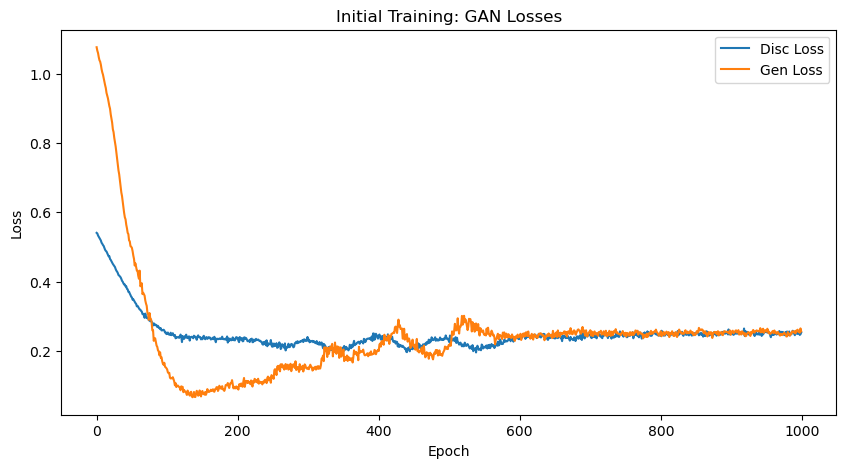

In [36]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(d_hist, label='Disc Loss')
plt.plot(g_hist, label='Gen Loss')
plt.title("Initial Training: GAN Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Using `ratio=0.2` creates a Shapre ratio of 2.2871, close to the paper's 2.3592 but exhibits higher volatility. The difference likely lies in the paper's training of the Discriminator and Regressor 5 times for every training of the Generator. Less initial epochs were used here as well. 

In [37]:

# Convert gross returns to simple net returns
# wealth_history is from GANr, each element is the value you end up with at the end of the day, if you started with $1 at the start of each day
net_returns = np.array(wealth_history) - 1
ai_cumulative_returns = np.cumprod(wealth_history)
ai_final_wealth = ai_cumulative_returns[-1]
ai_annual_return = ai_final_wealth - 1

# 2. Risk-Free Rate
rf_daily = 0.0 

# 3. Stats for Strategy
excess_returns = net_returns - rf_daily
avg_excess = np.mean(excess_returns)
std_dev = np.std(excess_returns)
annualized_volatility = std_dev * np.sqrt(len(net_returns))
sharpe_ratio = (ai_annual_return-rf_daily)/annualized_volatility


# Calculate Quantiles
q_levels = [0.1, 0.25, 0.5, 0.75, 0.9]
quantiles = np.quantile(np.array(wealth_history), q_levels)


print(f"--- Backtest Results (GANr) ---")
print(f"Total Test Days:         {len(net_returns)}")
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.4f}")
print(f"Annual Volatility: {annualized_volatility:.6f}")
print(f"\n--- Daily Gross Return Qunatiles ---")
for q, val in zip(q_levels, quantiles):
    print(f"{int(q*100)}th percentile: {val:.6f}")

--- Backtest Results (GANr) ---
Total Test Days:         251
Annualized Sharpe Ratio: 2.2871
Annual Volatility: 0.131406

--- Daily Gross Return Qunatiles ---
10th percentile: 0.992231
25th percentile: 0.997014
50th percentile: 1.000993
75th percentile: 1.005464
90th percentile: 1.010347


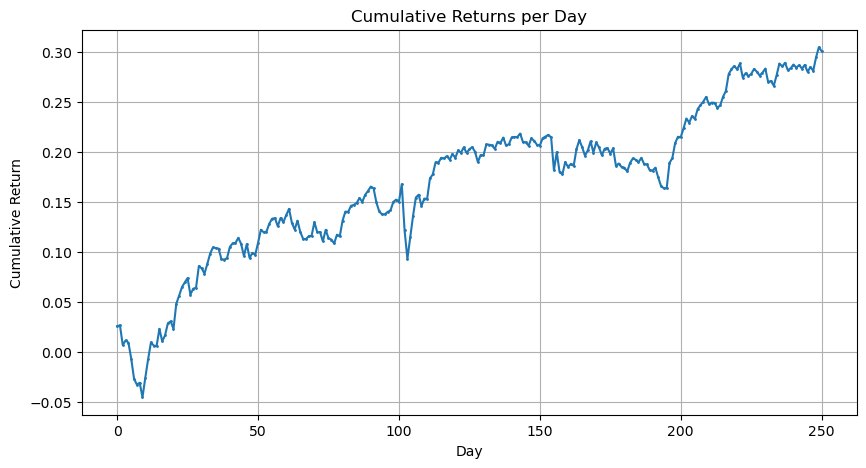

In [38]:

# Mimic Pun's plotting type in Fig. 2 of his paper
ai_cumulative_returns_for_plotting = ai_cumulative_returns - 1


# Plot
plt.figure(figsize=(10, 5))
plt.plot(ai_cumulative_returns_for_plotting, marker='o', markersize=1)
plt.title("Cumulative Returns per Day")
plt.xlabel("Day")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()


# References


Financial Thought Experiment: A GAN-based Approach to Vast Robust Portfolio
Selection:  
https://www.ijcai.org/proceedings/2020/0637.pdf


Data: Choose the specific file *sp500-0317*.  
https://data.mendeley.com/datasets/ndxfrshm74/3

<span style="color:red">


# Disclaimer

This work is strictly that of the author, Xiyang Foo. Neither Pun, Wang, nor Wong endorse nor verify it. Gratitude is extended to Professor Pun Chi Seng of Nanyang Technological University for his generosity and willingness to share and discuss his work. 

</span>